<a href="https://colab.research.google.com/github/AronJoseph96/AI-ML/blob/main/PredWeightWithLR.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

#Age vs Weight
data = {
    "Age": [10, 15, 20, 25, 30, 35, 40, 45, 50],
    "Weight": [30, 45, 55, 65, 70, 75, 80, 85, 90]
}

df = pd.DataFrame(data)

X = df["Age"].values
y = df["Weight"].values

X_max = max(X)
y_max = max(y)

X = X / X_max
y = y / y_max


print(df)

   Age  Weight
0   10      30
1   15      45
2   20      55
3   25      65
4   30      70
5   35      75
6   40      80
7   45      85
8   50      90


In [ ]:
indices = np.arange(len(X))
np.random.shuffle(indices)

X = X[indices]
y = y[indices]


# 80% train, 20% test
split = int(0.8* len(X))

X_train = X[:split]
y_train = y[:split]

X_test = X[split:]
y_test = y[split:]


In [ ]:
#initializing parameters
m = 0.1
c = 0

learning_rate = 0.01
epochs = 5000
n = len(X_train)

In [ ]:
for epoch in range(epochs):
  #predicting y
  y_pred = m * X_train + c

  #calculate loss
  loss = (1/n) * sum((y_train - y_pred) ** 2)

  #Finding gradients
  dm = (-2/n) *sum(X_train*(y_train - y_pred))
  dc = (-2/n) *sum(y_train - y_pred)

  #update parameters
  m = m - learning_rate* dm
  c = c - learning_rate* dc
  #print progress
  if epoch%500==0:
    print(f'Epoch{epoch}, Loss:{loss}')


Epoch0, Loss:0.5087335097001763
Epoch500, Loss:0.0024836759418582193
Epoch1000, Loss:0.001591628222340916
Epoch1500, Loss:0.0011557023612937913
Epoch2000, Loss:0.0009426741205041242
Epoch2500, Loss:0.0008385714841867115
Epoch3000, Loss:0.0007876986100172512
Epoch3500, Loss:0.0007628380549168882
Epoch4000, Loss:0.000750689199362955
Epoch4500, Loss:0.0007447522968813164


In [ ]:
print('Final Slope(m): ',m)
print('Final Intercept(c): ',c)

Final Slope(m):  0.6824672586858042
Final Intercept(c):  0.34284413694369226


In [ ]:
y_test_pred_norm = m * X_test + c

y_test_pred = y_test_pred_norm * y_max
y_test_actual = y_test * y_max

print("\nActual:", y_test_actual)
print("Predicted:", y_test_pred)

test_loss = (1/len(X_test)) * sum((y_test_actual - y_test_pred) ** 2)
print("\nTest Loss:", test_loss)


Actual: [30. 85.]
Predicted: [43.14038298 86.13582028]

Test Loss: 86.97987629982018


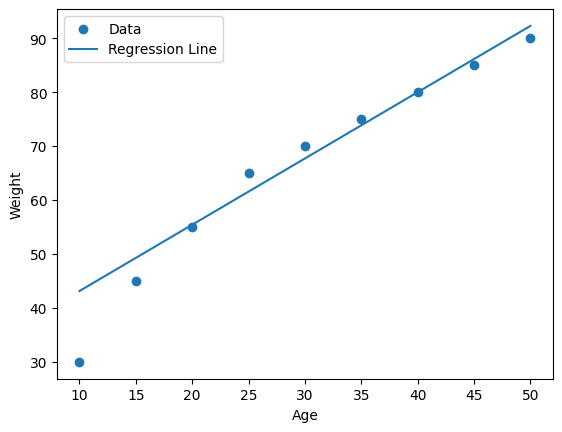

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df["Age"], df["Weight"], label='Data')

# Regression line
X_line = np.linspace(min(df["Age"]), max(df["Age"]), 100)
X_line_norm = X_line / X_max
y_line = (m * X_line_norm + c) * y_max

plt.plot(X_line, y_line, label='Regression Line')

plt.xlabel("Age")
plt.ylabel("Weight")
plt.legend()
plt.show()